Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Sample label: 5


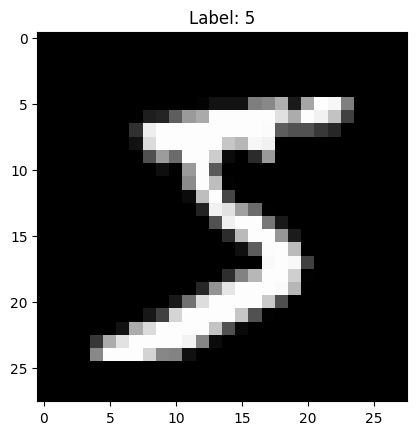

In [4]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Sample label:", y_train[0])

plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8792 - loss: 0.4186
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9647 - loss: 0.1193
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9772 - loss: 0.0763
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9830 - loss: 0.0565
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9863 - loss: 0.0450


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9714 - loss: 0.0945
✅ Test Accuracy: 97.49%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
🔢 Predicted digit: 7


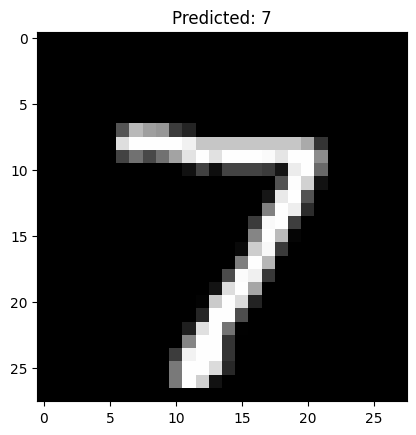

In [6]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {test_accuracy * 100:.2f}%")

sample = X_test[0]
prediction = model.predict(sample.reshape(1, 28, 28))
print(f"🔢 Predicted digit: {np.argmax(prediction)}")
plt.imshow(sample, cmap='gray')
plt.title(f"Predicted: {np.argmax(prediction)}")
plt.show()

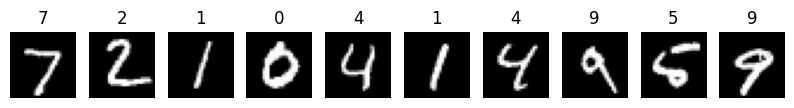

In [9]:
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(X_test[i], cmap='gray')
    pred = np.argmax(model.predict(X_test[i].reshape(1,28,28), verbose=0))
    plt.title(pred)
    plt.axis('off')
plt.show()